# AuraFitness Progressive Overload Engine Testing

This notebook tests the rule-based progressive overload engine.

Important:

- This is not ML training.
- Manual cases are used only for function testing.
- No fake dataset is used for model training or evaluation.
- Later, the React app will pass real user workout history into this engine.

Engine output:

- increase weight
- keep same weight
- reduce weight
- increase reps
- increase duration
- reduce volume
- rest/recover

In [1]:
from pathlib import Path
import sys
from dataclasses import asdict

import pandas as pd
import matplotlib.pyplot as plt

AI_ROOT = Path.cwd()

if AI_ROOT.name == "notebooks":
    AI_ROOT = AI_ROOT.parent

if str(AI_ROOT) not in sys.path:
    sys.path.append(str(AI_ROOT))

from utils.overload_engine import OverloadRequest, recommend_overload

REPORTS_DIR = AI_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("AI root:", AI_ROOT)

AI root: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai


## Controlled test cases

These are small manual function tests.

They are not used as training data.
They only verify that the rule-based engine behaves correctly for common workout scenarios.

In [2]:
test_cases = [
    (
        "Completed strength workout easily",
        OverloadRequest(
            exercise_name="Dumbbell Bench Press",
            exercise_type="strength",
            planned_sets=3,
            completed_sets=3,
            planned_reps=10,
            completed_reps=10,
            current_weight_kg=20,
            previous_weight_kg=18,
            rpe=7,
            pain_reported=False,
        ),
    ),
    (
        "Completed strength workout but too hard",
        OverloadRequest(
            exercise_name="Barbell Squat",
            exercise_type="strength",
            planned_sets=4,
            completed_sets=4,
            planned_reps=8,
            completed_reps=8,
            current_weight_kg=80,
            previous_weight_kg=80,
            rpe=9,
            pain_reported=False,
        ),
    ),
    (
        "Missed too much volume",
        OverloadRequest(
            exercise_name="Lat Pulldown",
            exercise_type="strength",
            planned_sets=4,
            completed_sets=2,
            planned_reps=12,
            completed_reps=7,
            current_weight_kg=55,
            previous_weight_kg=55,
            rpe=10,
            pain_reported=False,
        ),
    ),
    (
        "Pain reported",
        OverloadRequest(
            exercise_name="Shoulder Press",
            exercise_type="strength",
            planned_sets=3,
            completed_sets=2,
            planned_reps=10,
            completed_reps=6,
            current_weight_kg=25,
            previous_weight_kg=25,
            rpe=8,
            pain_reported=True,
        ),
    ),
    (
        "Completed cardio duration easily",
        OverloadRequest(
            exercise_name="Treadmill Walk",
            exercise_type="cardio",
            planned_duration_seconds=900,
            completed_duration_seconds=900,
            rpe=6,
            pain_reported=False,
        ),
    ),
]

## Run overload recommendations

This cell runs the rule-based engine and stores the results for review.

In [3]:
rows = []

for title, request in test_cases:
    recommendation = recommend_overload(request)

    row = {
        "test_case": title,
        "exercise_name": request.exercise_name,
        "exercise_type": request.exercise_type,
        "planned_sets": request.planned_sets,
        "completed_sets": request.completed_sets,
        "planned_reps": request.planned_reps,
        "completed_reps": request.completed_reps,
        "current_weight_kg": request.current_weight_kg,
        "planned_duration_seconds": request.planned_duration_seconds,
        "completed_duration_seconds": request.completed_duration_seconds,
        "rpe": request.rpe,
        "pain_reported": request.pain_reported,
        **asdict(recommendation),
    }

    rows.append(row)

results_df = pd.DataFrame(rows)
display(results_df)

,test_case,exercise_name,exercise_type,planned_sets,completed_sets,planned_reps,completed_reps,current_weight_kg,planned_duration_seconds,completed_duration_seconds,rpe,pain_reported,action,title,message,confidence,next_weight_kg,next_reps,next_duration_seconds,reason_codes
0,Completed strength workout easily,Dumbbell Bench Press,strength,3,3,10,10,20.0,NaN,NaN,7,False,increase_weight,Progress next session,You completed all planned work for Dumbbell Be...,0.85,21.0,10.0,NaN,"[completed_all_sets_and_reps, low_to_moderate_..."
1,Completed strength workout but too hard,Barbell Squat,strength,4,4,8,8,80.0,NaN,NaN,9,False,keep_same_weight,Repeat the same load,"You completed Barbell Squat, but it was very h...",0.82,80.0,8.0,NaN,"[completed_all_sets_and_reps, high_rpe]"
2,Missed too much volume,Lat Pulldown,strength,4,2,12,7,55.0,NaN,NaN,10,False,reduce_weight,Reduce intensity,You missed a large part of the planned work fo...,0.88,49.5,12.0,NaN,[large_missed_volume]
3,Pain reported,Shoulder Press,strength,3,2,10,6,25.0,NaN,NaN,8,True,rest_recover,Prioritize recovery,You reported pain during Shoulder Press. Do no...,0.95,22.5,10.0,NaN,[pain_reported]
4,Completed cardio duration easily,Treadmill Walk,cardio,3,3,10,10,NaN,900.0,900.0,6,False,increase_duration,Increase duration slightly,You completed the planned duration for Treadmi...,0.82,NaN,NaN,930.0,"[completed_duration, duration_easy_enough]"


## Chart overload actions

This chart shows which action the engine selected for each controlled test case.

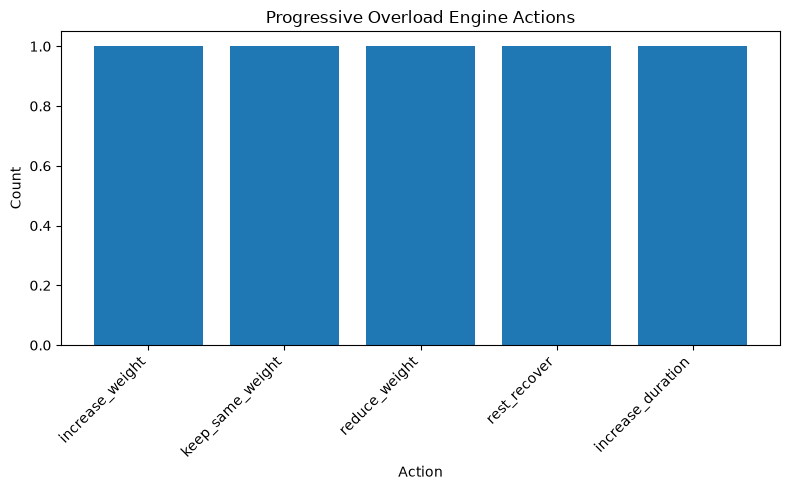

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\overload_engine_actions.png


In [4]:
action_counts = results_df["action"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(action_counts.index, action_counts.values)
plt.title("Progressive Overload Engine Actions")
plt.xlabel("Action")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = FIGURES_DIR / "overload_engine_actions.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## Chart confidence by test case

This chart shows the confidence score for each engine decision.

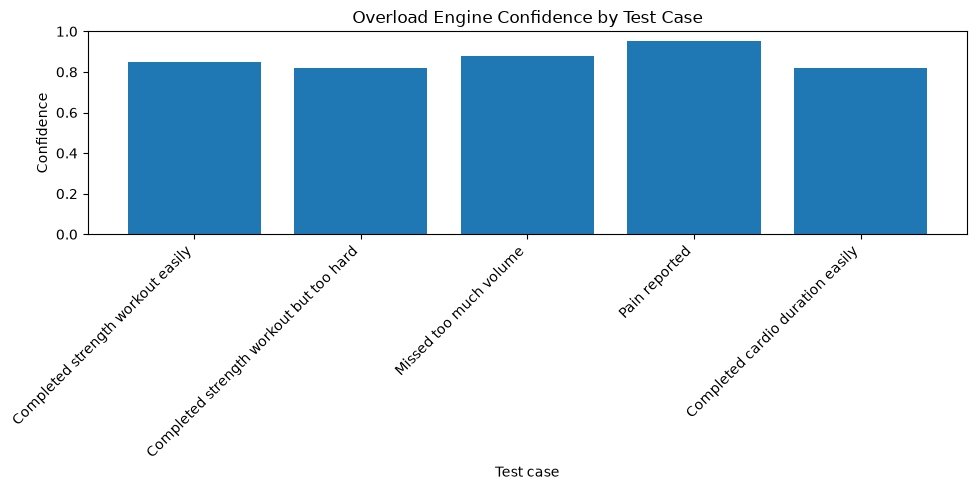

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\overload_engine_confidence.png


In [5]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["test_case"], results_df["confidence"])
plt.title("Overload Engine Confidence by Test Case")
plt.xlabel("Test case")
plt.ylabel("Confidence")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = FIGURES_DIR / "overload_engine_confidence.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## Save overload engine test results

This saves the logic verification results for documentation.

In [6]:
output_path = REPORTS_DIR / "overload_engine_test_results.csv"
results_df.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\overload_engine_test_results.csv


## Edge-case validation test

This section checks whether the overload engine handles invalid app inputs safely.

Example:
- RPE outside the valid 1-10 range

Expected behavior:
- Do not progress the user
- Keep the same target
- Return a warning reason code

In [7]:
edge_case_request = OverloadRequest(
    exercise_name="Dumbbell Curl",
    exercise_type="strength",
    planned_sets=3,
    completed_sets=3,
    planned_reps=10,
    completed_reps=10,
    current_weight_kg=12,
    previous_weight_kg=12,
    rpe=15,
    pain_reported=False,
)

edge_case_result = recommend_overload(edge_case_request)

edge_case_row = {
    "exercise_name": edge_case_request.exercise_name,
    "action": edge_case_result.action,
    "title": edge_case_result.title,
    "message": edge_case_result.message,
    "confidence": edge_case_result.confidence,
    "reason_codes": edge_case_result.reason_codes,
}

display(pd.DataFrame([edge_case_row]))

if edge_case_result.action != "keep_same_weight":
    raise ValueError("Invalid input should not trigger progression.")

if "rpe_out_of_range" not in edge_case_result.reason_codes:
    raise ValueError("Expected rpe_out_of_range warning code.")

print("Edge-case validation passed.")

,exercise_name,action,title,message,confidence,reason_codes
0,Dumbbell Curl,keep_same_weight,Check workout input,Some workout values look invalid or unusual. K...,0.6,[rpe_out_of_range]


Edge-case validation passed.
